# Data Exploration

Basic exploration of the Superstore sales dataset.

In [23]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_prep.load_data import load_superstore
from data_prep.preprocess import clean_columns

sns.set_theme(style="whitegrid")

In [24]:
df = load_superstore("../data/raw/Sample - Superstore.csv")
df = clean_columns(df)
print(df.shape)
df.head()

(9994, 21)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
#df.head(20)

## Basic info

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub_category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

In [26]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [27]:
# Missing values
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [28]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Column overview

In [29]:
# Unique values per categorical column
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

order_id: 5009 unique values
order_date: 1237 unique values
ship_date: 1334 unique values
ship_mode: 4 unique values
customer_id: 793 unique values
customer_name: 793 unique values
segment: 3 unique values
country: 1 unique values
city: 531 unique values
state: 49 unique values
region: 4 unique values
product_id: 1862 unique values
category: 3 unique values
sub_category: 17 unique values
product_name: 1850 unique values


C:\Users\mohan\AppData\Local\Temp\ipykernel_28360\1972402615.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


## Sales by category

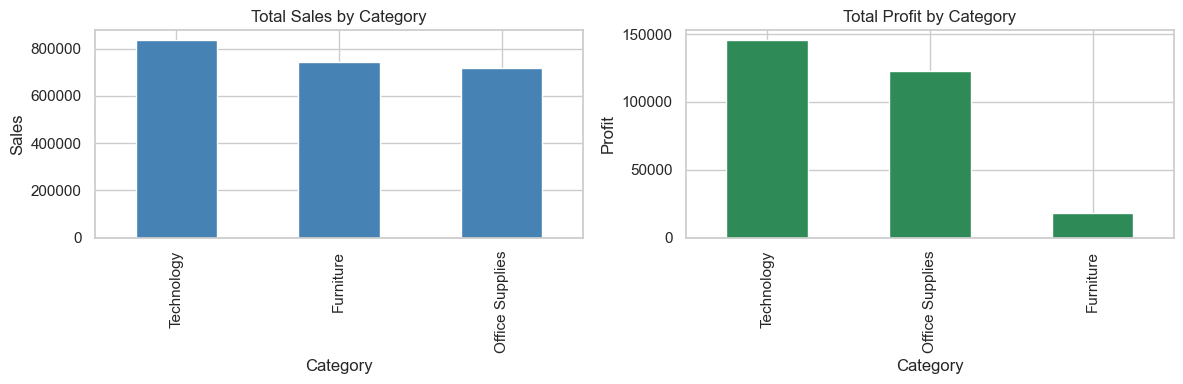

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sales_by_cat = df.groupby("category")["sales"].sum().sort_values(ascending=False)
sales_by_cat.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Sales")

profit_by_cat = df.groupby("category")["profit"].sum().sort_values(ascending=False)
profit_by_cat.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Total Profit by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Profit")

plt.tight_layout()
plt.show()

## Sales by region

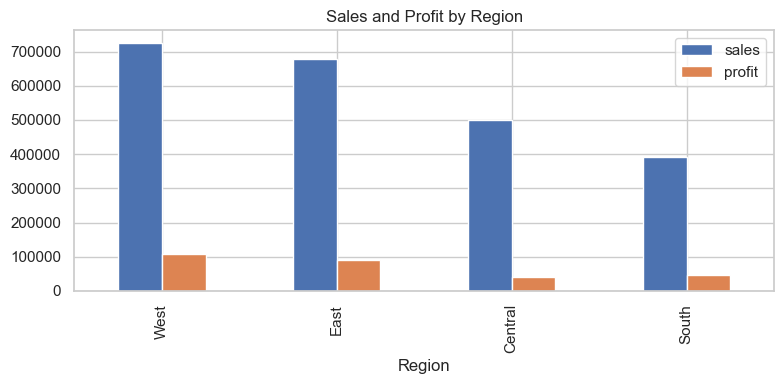

In [31]:
region_summary = df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
region_summary.plot(kind="bar", figsize=(8, 4))
plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

## Sales over time

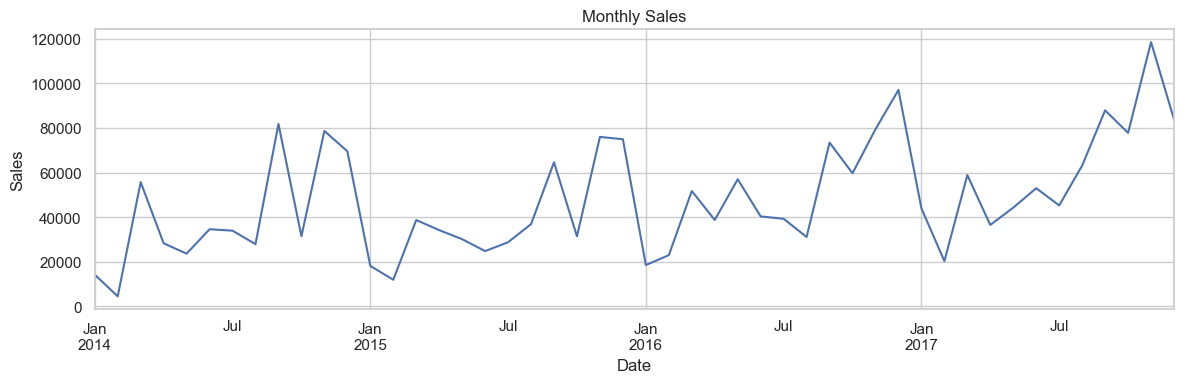

In [32]:
df["order_date"] = pd.to_datetime(df["order_date"])
monthly_sales = df.resample("ME", on="order_date")["sales"].sum()

monthly_sales.plot(figsize=(12, 4))
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## Top 10 products by sales

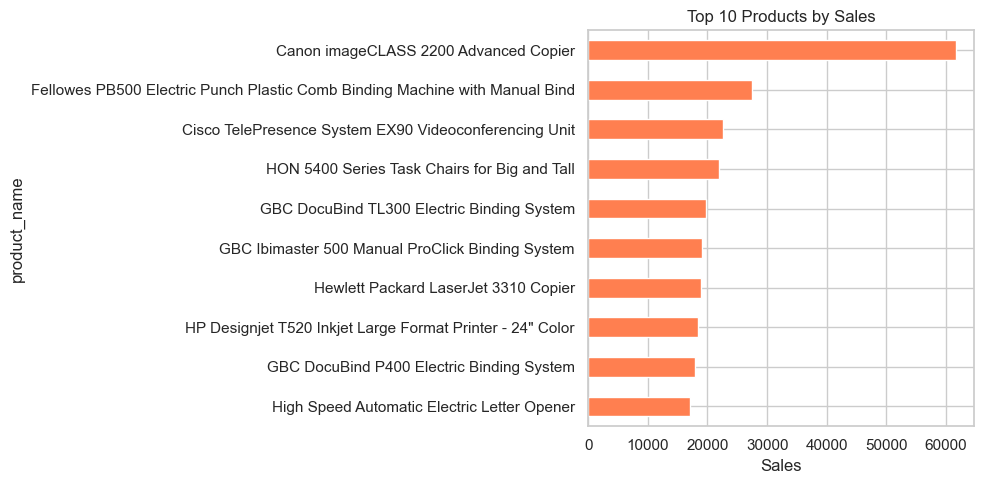

In [33]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="barh", figsize=(10, 5), color="coral")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()